<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 1: Implementación de un modelo por Random Forest</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> En esta actividad construiras un clasificadore basados en **Random Forest** para predecir la **aceptabilidad/seguridad de un automóvil**. 
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales:</b>
<ul>
<li>Entrenar dos modelos (con pocos y con muchos árboles) para observar cómo mejora la exactitud, demostrar el proceso de **selección de características** basado en la importancia de variables, y reconstruir el modelo con las variables más relevantes. </li>

</ul>
</div>

**Random Forest** (bosque aleatorio) es un algoritmo de **aprendizaje supervisado** basado en **ensamble** (*ensemble learning*). Tiene dos variantes: una para **clasificación** y otra para **regresión**. Es uno de los algoritmos más flexibles y fáciles de usar.

Construye **múltiples árboles de decisión** sobre distintas muestras de los datos, obtiene la predicción de cada árbol y selecciona la mejor solución mediante **votación**. Además, es un excelente indicador de la **importancia de las variables**.

> Al combinar muchos árboles se forma un "bosque"; de ahí el nombre **Random Forest**. Cuantos **más árboles**, mayor suele ser la exactitud (hasta estabilizarse).

#### Selección de características con Random Forest

El Random Forest permite **ordenar la importancia** de las variables. Durante el entrenamiento, se registra el **error out-of-bag (OOB)** y se promedia sobre el bosque.

Para medir la importancia de la característica *j*, se **permutan** sus valores en los datos y se recalcula el error OOB sobre ese conjunto perturbado. La **importancia** es la diferencia promedio de error OOB antes y después de la permutación, normalizada por su desviación estándar.

Las características que producen valores **grandes** de esta puntuación son más importantes. Con base en ella, conservaremos las más relevantes y descartaremos las menos útiles.

**Planteamiento del problema**

El objetivo es **predecir la aceptabilidad/seguridad de un automóvil** con un clasificador Random Forest en Python y scikit-learn, usando el [**Car Evaluation Data Set**](http://archive.ics.uci.edu/ml/datasets/Car+Evaluation) de la UCI.

El **Car Evaluation Data Set** relaciona la evaluación del automóvil (`class`) con **seis atributos de entrada**:

| Variable | Descripción | Valores |
|---|---|---|
| `buying` | Precio de compra | vhigh, high, med, low |
| `maint` | Costo de mantenimiento | vhigh, high, med, low |
| `doors` | Número de puertas | 2, 3, 4, 5more |
| `persons` | Capacidad de personas | 2, 4, more |
| `lug_boot` | Tamaño de la cajuela | small, med, big |
| `safety` | Seguridad estimada | low, med, high |
| `class` | **Objetivo:** evaluación | unacc, acc, good, vgood |

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [6]:
# Dataset real de la UCI (se descarga al vuelo)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'
df = pd.read_csv(url, header=None)

# Alternativa local: df = pd.read_csv('C:/datasets/car.data', header=None)
df.shape

(1728, 7)

## 1.- Análisis exploratorio de datos

In [7]:
# Primeras filas (columnas aún sin nombre)
# Primeras filas del DataFrame
df.columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [10]:
# Análisis de distribución de frecuencias para cada atributo categórico
for columna in df.columns:
    print(f"--- Distribución para {columna} ---")
    print(df[columna].value_counts(normalize=True).round(3) * 100)
    print("\n")

--- Distribución para buying ---
buying
vhigh    25.0
high     25.0
med      25.0
low      25.0
Name: proportion, dtype: float64


--- Distribución para maint ---
maint
vhigh    25.0
high     25.0
med      25.0
low      25.0
Name: proportion, dtype: float64


--- Distribución para doors ---
doors
2        25.0
3        25.0
4        25.0
5more    25.0
Name: proportion, dtype: float64


--- Distribución para persons ---
persons
2       33.3
4       33.3
more    33.3
Name: proportion, dtype: float64


--- Distribución para lug_boot ---
lug_boot
small    33.3
med      33.3
big      33.3
Name: proportion, dtype: float64


--- Distribución para safety ---
safety
low     33.3
med     33.3
high    33.3
Name: proportion, dtype: float64


--- Distribución para class ---
class
unacc    70.0
acc      22.2
good      4.0
vgood     3.8
Name: proportion, dtype: float64




### Variable objetivo `class` y valores faltantes
La variable objetivo es **ordinal** (unacc < acc < good < vgood).

In [ ]:
# 1. Inspeccionar la distribución absoluta de la variable objetivo 'class'
print("Conteo de registros por categoría en 'class':")
print(df['class'].value_counts())

# 2. Comprobar formalmente si existen valores faltantes/nulos en el dataset
print("\nConteo de valores nulos o faltantes por columna:")
print(df.isnull().sum())

Conteo de registros por categoría en 'class':


## 2. Definir variables predictoras y objetivo

In [11]:
# Asignación de matrices predictoras (features) y variable objetivo (target)
X_features = df.drop(columns=['class'])
y_target = df['class']

print(f"Dimensiones de X (predictoras): {X_features.shape}")
print(f"Dimensiones de y (objetivo): {y_target.shape}")

Dimensiones de X (predictoras): (1728, 6)
Dimensiones de y (objetivo): (1728,)


## 3. Dividir en entrenamiento y prueba

In [12]:
from sklearn.model_selection import train_test_split

# Dividir dataset manteniendo la proporción de clases (stratify) y usando semilla propia
X_train, X_test, y_train, y_test = train_test_split(
    X_features, 
    y_target, 
    test_size=0.33, 
    random_state=123,
    stratify=y_target
)

print(f"Conjunto de entrenamiento: {X_train.shape}")
print(f"Conjunto de prueba: {X_test.shape}")

Conjunto de entrenamiento: (1157, 6)
Conjunto de prueba: (571, 6)


## 4. Ingeniería de características (codificación)

Todas las variables son **categóricas ordinales**; las convertimos a números con `OrdinalEncoder` de scikit-learn (sin dependencias externas).

In [13]:
from sklearn.preprocessing import OrdinalEncoder

# Definición explícita de categorías ordinales
niveles_categorias = [
    ['low', 'med', 'high', 'vhigh'],   # buying
    ['low', 'med', 'high', 'vhigh'],   # maint
    ['2', '3', '4', '5more'],          # doors
    ['2', '4', 'more'],                # persons
    ['small', 'med', 'big'],           # lug_boot
    ['low', 'med', 'high']             # safety
]

codificador = OrdinalEncoder(categories=niveles_categorias)

# Ajuste y transformación de características
X_train_encoded = pd.DataFrame(codificador.fit_transform(X_train), columns=X_train.columns)
X_test_encoded = pd.DataFrame(codificador.transform(X_test), columns=X_test.columns)

X_train_encoded.head()

,buying,maint,doors,persons,lug_boot,safety
0,0.0,1.0,0.0,1.0,0.0,0.0
1,1.0,1.0,1.0,1.0,0.0,0.0
2,0.0,0.0,0.0,2.0,2.0,0.0
3,2.0,2.0,1.0,1.0,0.0,0.0
4,0.0,1.0,1.0,0.0,2.0,1.0


## 5. Random Forest con pocos árboles (modelo 1)

Entrena un bosque con **10 árboles** para tener una referencia.


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Modelo 1: Configuración base con 10 estimadores
modelo_rf_10 = RandomForestClassifier(n_estimators=10, random_state=123)
modelo_rf_10.fit(X_train_encoded, y_train)

# Predicción y evaluación
predicciones_10 = modelo_rf_10.predict(X_test_encoded)
exactitud_10 = accuracy_score(y_test, predicciones_10)

print(f"Exactitud obtenida con 10 árboles: {exactitud_10:.4f}")

Exactitud obtenida con 10 árboles: 0.9562


## 6. Random Forest con muchos arboles `n_estimators=100`

Entrena un modelo con **100 árboles** y comenta lo que puedas observar.

In [15]:
# Modelo 2: Configuración con 100 estimadores
modelo_rf_100 = RandomForestClassifier(n_estimators=100, random_state=123)
modelo_rf_100.fit(X_train_encoded, y_train)

# Predicción y evaluación
predicciones_100 = modelo_rf_100.predict(X_test_encoded)
exactitud_100 = accuracy_score(y_test, predicciones_100)

print(f"Exactitud obtenida con 100 árboles: {exactitud_100:.4f}")

Exactitud obtenida con 100 árboles: 0.9720


## 7. Importancia de las características

Usa el atributo `feature_importances_` del bosque para ordenar las variables por relevancia.

In [16]:
# Extracción y ordenamiento de la importancia de variables
importancias = pd.Series(modelo_rf_100.feature_importances_, index=X_train_encoded.columns)
importancias_ordenadas = importancias.sort_values(ascending=False)

print("Puntuaciones de importancia por variable:")
print(importancias_ordenadas)

Puntuaciones de importancia por variable:
safety      0.297671
persons     0.252258
buying      0.149477
maint       0.145340
lug_boot    0.090292
doors       0.064962
dtype: float64


## 8. Visualizar la importancia de las características

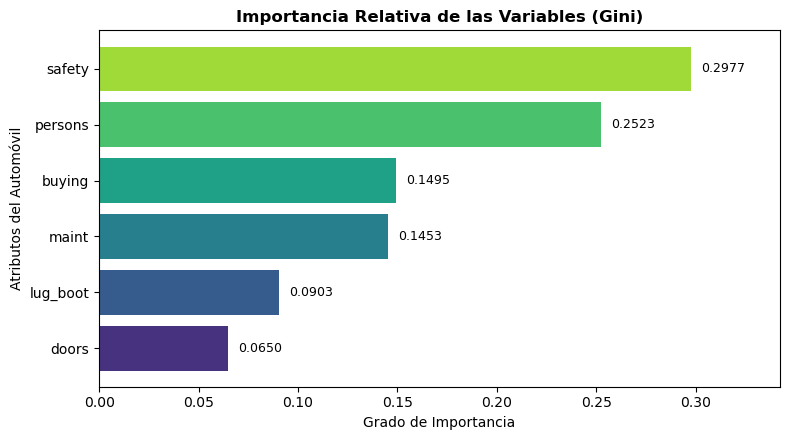

In [17]:
# Gráfica horizontal personalizada con paleta viridis y formato limpio
plt.figure(figsize=(8, 4.5))
barras = plt.barh(importancias_ordenadas.index[::-1], importancias_ordenadas.values[::-1], color=sns.color_palette("viridis", 6))

plt.title("Importancia Relativa de las Variables (Gini)", fontsize=12, fontweight='bold')
plt.xlabel("Grado de Importancia")
plt.ylabel("Atributos del Automóvil")

# Agregar los valores numéricos exactos a cada barra
for barra in barras:
    ancho = barra.get_width()
    plt.text(ancho + 0.005, barra.get_y() + barra.get_height()/2, f"{ancho:.4f}", va='center', fontsize=9)

plt.xlim(0, max(importancias_ordenadas.values) * 1.15)
plt.tight_layout()
plt.show()

## 9. Reconstruir el modelo con las características seleccionadas

Elimina la variable **menos importante**, reconstruye el modelo y compara la exactitud.

In [18]:
# Nuevo conjunto de variables sin 'doors'
variable_descartada = importancias_ordenadas.index[-1]
print(f"Variable eliminada del modelo: {variable_descartada}")

X_train_reducido = X_train_encoded.drop(columns=[variable_descartada])
X_test_reducido = X_test_encoded.drop(columns=[variable_descartada])

# Entrenamiento del modelo reconstruido
modelo_rf_reconstruido = RandomForestClassifier(n_estimators=100, random_state=123)
modelo_rf_reconstruido.fit(X_train_reducido, y_train)

# Predicción y comparación de métricas
predicciones_reconstruido = modelo_rf_reconstruido.predict(X_test_reducido)
exactitud_reconstruido = accuracy_score(y_test, predicciones_reconstruido)

print(f"Exactitud modelo completo (100 árboles): {exactitud_100:.4f}")
print(f"Exactitud modelo reducido (sin '{variable_descartada}'): {exactitud_reconstruido:.4f}")

Variable eliminada del modelo: doors
Exactitud modelo completo (100 árboles): 0.9720
Exactitud modelo reducido (sin 'doors'): 0.9387


## 10. Crea un Reporte de clasificación

Muestra **precision**, **recall**, **f1-score** y **support** por clase.

In [20]:
from sklearn.metrics import classification_report

# Métricas detalladas por categoría
print("Reporte de Clasificación (Modelo Reconstruido):")
print(classification_report(y_test, predicciones_reconstruido))

Reporte de Clasificación (Modelo Reconstruido):
              precision    recall  f1-score   support

         acc       0.91      0.86      0.88       127
        good       0.75      0.78      0.77        23
       unacc       0.97      0.97      0.97       400
       vgood       0.76      0.90      0.83        21

    accuracy                           0.94       571
   macro avg       0.85      0.88      0.86       571
weighted avg       0.94      0.94      0.94       571

